## **Imports & Config**

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **DataLoading**

In [48]:
data = pd.read_csv("G:\\disaster Event\\synthetic_disaster_events_2025.csv")

## **Data Understanding**

In [49]:
data.head()

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1


## **Research Questions**
### **Disaster**
- Which Type of Disaster Occured  more to each country's ?
- Which Disaster affected most population ?
- Which Disaster has high impacted severity_level ?
### **Location**
- which country has most Disasters ?
- which county is providing best response_time ?
- which country is has more economic-loss?
- country wise effected population?
- Which country has high severity-level ?
- Which county has high infrastructure-damage ?
### **Time & Trends**
- Is disaster increasing or decreasing over time according to country ?


In [50]:
data.columns

Index(['event_id', 'disaster_type', 'location', 'latitude', 'longitude',
       'date', 'severity_level', 'affected_population',
       'estimated_economic_loss_usd', 'response_time_hours', 'aid_provided',
       'infrastructure_damage_index', 'is_major_disaster'],
      dtype='object')

## **Columns Info**
* **event_id:** :- Unique identifier assigned to each disaster event.
* **disaster_type** :- Category or type of disaster that occurred.
* **location:** :- Country or region where the disaster took place.
* **latitude:** :- Geographic latitude coordinate of the disaster location.
* **longitude:** :- Geographic longitude coordinate of the disaster location.
* **date:** :- Date on which the disaster event occurred.
* **severity_level:** :- Numerical indicator representing the intensity of the disaster.
* **affected_population:** :- Total number of people directly impacted by the disaster.
* **estimated_economic_loss_usd**:- Estimated financial loss caused by the disaster in USD.
* **response_time_hours:** :- Time taken in hours for emergency response to begin.
* **aid_provided:** :- Type or status of humanitarian aid delivered to the affected area.
* **infrastructure_damage_index:** :- Index value indicating the extent of damage to infrastructure.


In [51]:
data.shape

(20000, 13)

In [52]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     20000 non-null  int64  
 1   disaster_type                20000 non-null  object 
 2   location                     20000 non-null  object 
 3   latitude                     20000 non-null  float64
 4   longitude                    20000 non-null  float64
 5   date                         20000 non-null  object 
 6   severity_level               20000 non-null  int64  
 7   affected_population          20000 non-null  int64  
 8   estimated_economic_loss_usd  20000 non-null  float64
 9   response_time_hours          20000 non-null  float64
 10  aid_provided                 20000 non-null  object 
 11  infrastructure_damage_index  20000 non-null  float64
 12  is_major_disaster            20000 non-null  int64  
dtypes: float64(5), i

## **Observatation**
- Columns names should properly capatilize
- date datatype should be change into Date-Time datatype 

## **Data Cleaning**

In [53]:
data[data.duplicated()]

,event_id,disaster_type,location,latitude,longitude,date,severity_level,affected_population,estimated_economic_loss_usd,response_time_hours,aid_provided,infrastructure_damage_index,is_major_disaster


## **Observatation**
- There is no duplicates in data 

In [54]:
data.isnull().sum()

event_id                       0
disaster_type                  0
location                       0
latitude                       0
longitude                      0
date                           0
severity_level                 0
affected_population            0
estimated_economic_loss_usd    0
response_time_hours            0
aid_provided                   0
infrastructure_damage_index    0
is_major_disaster              0
dtype: int64

## **Observatation**
- There is no null values in data

In [55]:
# making columns names Capitalize
data.columns = data.columns.str.capitalize()

In [56]:
data.head()

,Event_id,Disaster_type,Location,Latitude,Longitude,Date,Severity_level,Affected_population,Estimated_economic_loss_usd,Response_time_hours,Aid_provided,Infrastructure_damage_index,Is_major_disaster
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1


In [57]:
# adding new_column with round of estimated_economic_loss_usd
data['Economic_loss_rounded'] = data['Estimated_economic_loss_usd'].round(0)

In [58]:
data.head(2)

,Event_id,Disaster_type,Location,Latitude,Longitude,Date,Severity_level,Affected_population,Estimated_economic_loss_usd,Response_time_hours,Aid_provided,Infrastructure_damage_index,Is_major_disaster,Economic_loss_rounded
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1,2768213.0
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0,5996227.0


In [59]:
data.describe()

,Event_id,Latitude,Longitude,Severity_level,Affected_population,Estimated_economic_loss_usd,Response_time_hours,Infrastructure_damage_index,Is_major_disaster,Economic_loss_rounded
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000,2.000000e+04
mean,10000.500000,18.749811,41.976629,5.489300,27641.248950,4.831073e+06,36.369664,0.557306,0.40005,4.831073e+06
std,5773.647028,25.026759,82.535922,2.866269,16017.199074,3.624308e+06,20.420570,0.209064,0.48992,3.624308e+06
min,1.000000,-43.127383,-102.133704,1.000000,0.000000,0.000000e+00,1.000000,0.060000,0.00000,0.000000e+00
25%,5000.750000,3.560059,8.346726,3.000000,14755.000000,2.024090e+06,18.407500,0.400000,0.00000,2.024090e+06
50%,10000.500000,24.361006,74.600322,5.000000,27612.500000,4.031418e+06,36.560000,0.550000,0.00000,4.031418e+06
75%,15000.250000,38.285895,117.460836,8.000000,40016.500000,7.018268e+06,54.020000,0.700000,1.00000,7.018268e+06
max,20000.000000,48.452161,145.902669,10.000000,75147.000000,2.186893e+07,71.990000,1.000000,1.00000,2.186894e+07


In [60]:
cols = [
    'Affected_population',
    'Economic_loss_rounded',
    'Response_time_hours',
    'Infrastructure_damage_index'
]

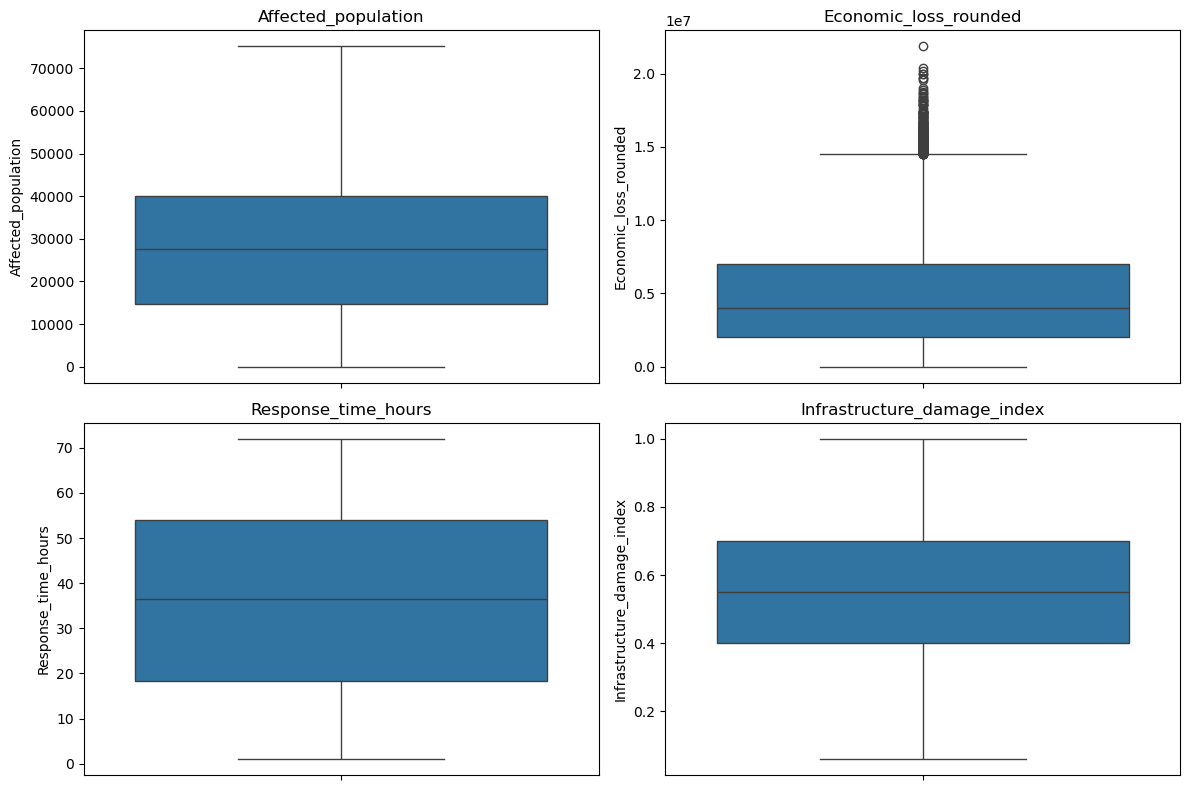

In [61]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [62]:
Q1 = data[cols].quantile(0.25)
Q2 = data[cols].quantile(0.50)
Q3 = data[cols].quantile(0.75)

IQR = Q3 - Q1

upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

print("Upper fence:\n", upper_fence)
print("\nLower fence:\n", lower_fence)

Upper fence:
 Affected_population            7.790875e+04
Economic_loss_rounded          1.450954e+07
Response_time_hours            1.074387e+02
Infrastructure_damage_index    1.150000e+00
dtype: float64

Lower fence:
 Affected_population           -2.313725e+04
Economic_loss_rounded         -5.467178e+06
Response_time_hours           -3.501125e+01
Infrastructure_damage_index   -5.000000e-02
dtype: float64


In [63]:
for col in cols:
    data[col] = data[col].clip(
        lower=lower_fence[col],
        upper=upper_fence[col]
    )

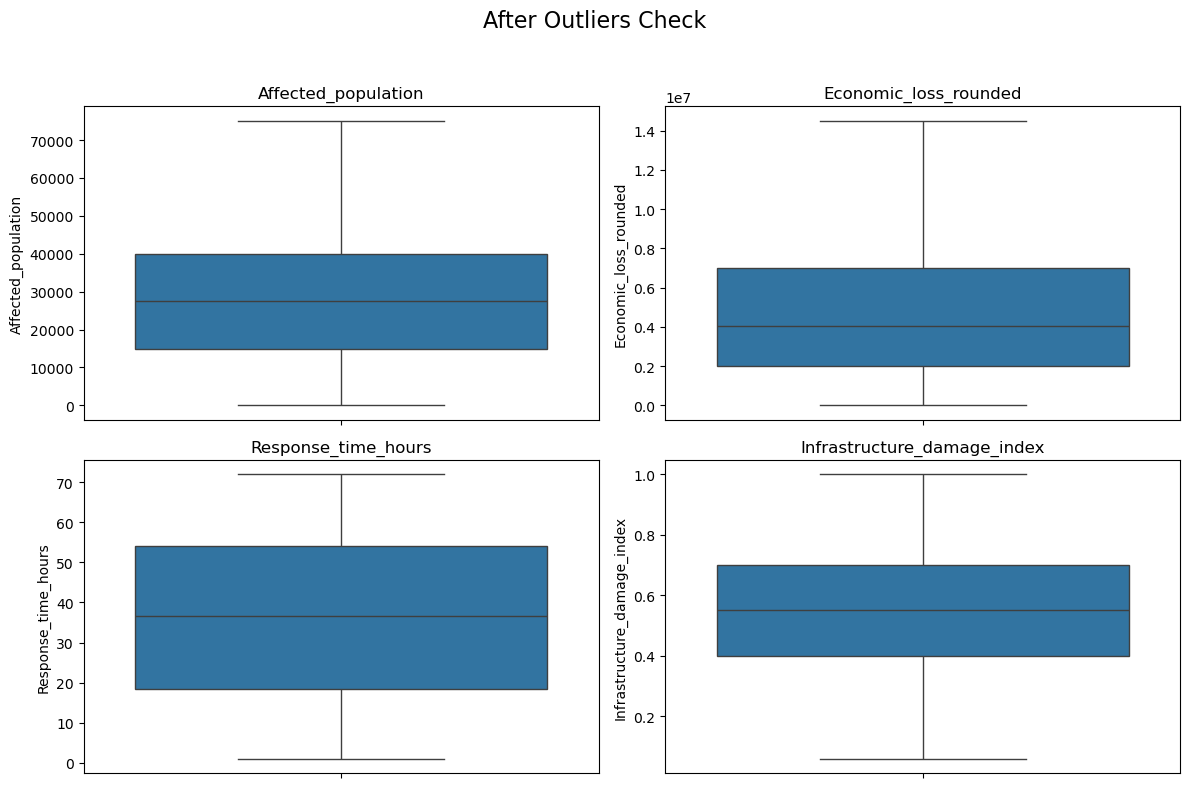

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cols):
    sns.boxplot(y=data[col], ax=axes[i])
    axes[i].set_title(col)

fig.suptitle('After Outliers Check', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [65]:
data.describe()

,Event_id,Latitude,Longitude,Severity_level,Affected_population,Estimated_economic_loss_usd,Response_time_hours,Infrastructure_damage_index,Is_major_disaster,Economic_loss_rounded
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.00000,2.000000e+04
mean,10000.500000,18.749811,41.976629,5.489300,27641.248950,4.831073e+06,36.369664,0.557306,0.40005,4.812580e+06
std,5773.647028,25.026759,82.535922,2.866269,16017.199074,3.624308e+06,20.420570,0.209064,0.48992,3.567918e+06
min,1.000000,-43.127383,-102.133704,1.000000,0.000000,0.000000e+00,1.000000,0.060000,0.00000,0.000000e+00
25%,5000.750000,3.560059,8.346726,3.000000,14755.000000,2.024090e+06,18.407500,0.400000,0.00000,2.024090e+06
50%,10000.500000,24.361006,74.600322,5.000000,27612.500000,4.031418e+06,36.560000,0.550000,0.00000,4.031418e+06
75%,15000.250000,38.285895,117.460836,8.000000,40016.500000,7.018268e+06,54.020000,0.700000,1.00000,7.018268e+06
max,20000.000000,48.452161,145.902669,10.000000,75147.000000,2.186893e+07,71.990000,1.000000,1.00000,1.450954e+07


In [66]:
# convering the Posting-data into date and time datet time datatime
data['Date'] = pd.to_datetime(
    data['Date'],
    format='%Y-%m-%d'
)

In [67]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Event_id                     20000 non-null  int64         
 1   Disaster_type                20000 non-null  object        
 2   Location                     20000 non-null  object        
 3   Latitude                     20000 non-null  float64       
 4   Longitude                    20000 non-null  float64       
 5   Date                         20000 non-null  datetime64[ns]
 6   Severity_level               20000 non-null  int64         
 7   Affected_population          20000 non-null  int64         
 8   Estimated_economic_loss_usd  20000 non-null  float64       
 9   Response_time_hours          20000 non-null  float64       
 10  Aid_provided                 20000 non-null  object        
 11  Infrastructure_damage_index  20000 non-nu

In [68]:
#adding a new date column as per Posted_date
data['Month']=data['Date'].dt.month
data['Month_Name']=data['Date'].dt.month_name()
data['Year'] = data['Date'].dt.year

In [69]:
data.head()

,Event_id,Disaster_type,Location,Latitude,Longitude,Date,Severity_level,Affected_population,Estimated_economic_loss_usd,Response_time_hours,Aid_provided,Infrastructure_damage_index,Is_major_disaster,Economic_loss_rounded,Month,Month_Name,Year
0,1,Wildfire,Chile,-34.681672,-71.819529,2025-08-27,8,31104,2768213.39,5.12,Yes,0.59,1,2768213.0,8,August,2025
1,2,Hurricane,India,22.128569,78.023951,2023-05-29,5,29340,5996226.87,44.43,No,0.26,0,5996227.0,5,May,2023
2,3,Volcanic Eruption,Italy,42.316058,11.031447,2023-01-15,7,34804,9222541.48,49.30,No,0.94,1,9222541.0,1,January,2023
3,4,Drought,Chile,-33.436253,-69.984615,2024-02-08,8,31191,1827703.09,65.56,Yes,0.94,1,1827703.0,2,February,2024
4,5,Volcanic Eruption,Turkey,39.400977,37.006822,2023-12-23,8,46284,13435921.49,60.96,No,0.92,1,13435921.0,12,December,2023


In [70]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Event_id                     20000 non-null  int64         
 1   Disaster_type                20000 non-null  object        
 2   Location                     20000 non-null  object        
 3   Latitude                     20000 non-null  float64       
 4   Longitude                    20000 non-null  float64       
 5   Date                         20000 non-null  datetime64[ns]
 6   Severity_level               20000 non-null  int64         
 7   Affected_population          20000 non-null  int64         
 8   Estimated_economic_loss_usd  20000 non-null  float64       
 9   Response_time_hours          20000 non-null  float64       
 10  Aid_provided                 20000 non-null  object        
 11  Infrastructure_damage_index  20000 non-nu

## **Analysis**

In [71]:
disasters_affected_population = (
    data.groupby('Disaster_type')['Affected_population']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)
disasters_affected_population

Disaster_type
Volcanic Eruption    27866.127697
Earthquake           27838.172165
Hurricane            27817.130147
Landslide            27747.980284
Wildfire             27506.820557
Drought              27401.360112
Flood                27299.091237
Name: Affected_population, dtype: float64

In [72]:
disaster_severity_level = (
    data.groupby('Disaster_type')['Severity_level']
    .mean()
    .sort_values(ascending=False)
)
disaster_severity_level

Disaster_type
Volcanic Eruption    5.546869
Earthquake           5.506186
Wildfire             5.503136
Landslide            5.501557
Hurricane            5.495115
Drought              5.449528
Flood                5.420844
Name: Severity_level, dtype: float64

In [73]:
location_disaster = (
    data.groupby('Location')['Disaster_type']
    .count()
    .sort_values(ascending=False)
)
location_disaster

Location
India          2583
Indonesia      2530
Chile          2515
Turkey         2515
Italy          2485
Japan          2477
Philippines    2453
USA            2442
Name: Disaster_type, dtype: int64

In [74]:
countries_avg_response_time = (
    data.groupby('Location')['Response_time_hours']
    .mean()
    .sort_values(ascending=False)
)
countries_avg_response_time

Location
Turkey         37.004620
Japan          36.873476
Chile          36.547352
Indonesia      36.527012
USA            36.253546
India          36.145881
Italy          35.973988
Philippines    35.617530
Name: Response_time_hours, dtype: float64

In [75]:
countryies_affected_population =(
    data.groupby('Location')['Affected_population']
    .sum()
    .sort_values(ascending=False)
)
countryies_affected_population

Location
India          72183422
Indonesia      70193413
Chile          70115117
Italy          69355495
Turkey         68387863
Japan          67861716
USA            67448482
Philippines    67279471
Name: Affected_population, dtype: int64

In [76]:
countryies_affected_severity_level = (
    data.groupby('Location')['Severity_level']
    .mean()
    .sort_values(ascending=False)
)
countryies_affected_severity_level

Location
Chile          5.563419
India          5.538134
Indonesia      5.506324
Italy          5.481288
USA            5.481163
Turkey         5.458449
Philippines    5.456991
Japan          5.425111
Name: Severity_level, dtype: float64

In [77]:
countryies_economic_loss =(
    data.groupby('Location')['Economic_loss_rounded']
    .sum()
    .sort_values(ascending=False)
)
countryies_economic_loss

Location
India          1.261136e+10
Indonesia      1.228042e+10
Chile          1.219417e+10
Italy          1.208362e+10
USA            1.189575e+10
Philippines    1.182054e+10
Turkey         1.175159e+10
Japan          1.161415e+10
Name: Economic_loss_rounded, dtype: float64

In [78]:
country_loss_billions = countryies_economic_loss / 1e9
country_loss_billions.round(2)


Location
India          12.61
Indonesia      12.28
Chile          12.19
Italy          12.08
USA            11.90
Philippines    11.82
Turkey         11.75
Japan          11.61
Name: Economic_loss_rounded, dtype: float64

In [79]:
country_insfrastrure_damage = (
    data.groupby('Location')['Infrastructure_damage_index']
    .mean()
    .sort_values(ascending=False)
)
country_insfrastrure_damage

Location
Chile          0.563583
Indonesia      0.563245
Philippines    0.557521
USA            0.557228
Turkey         0.556060
India          0.556005
Japan          0.552483
Italy          0.552193
Name: Infrastructure_damage_index, dtype: float64

In [80]:
pivot_table = pd.pivot_table(
    data,
    index='Location',
    columns='Disaster_type',
    values='Event_id', 
    aggfunc='count',
    fill_value=0
)
pivot_table


Disaster_type,Drought,Earthquake,Flood,Hurricane,Landslide,Volcanic Eruption,Wildfire
Location,,,,,,,
Chile,341,368,353,378,357,369,349
India,368,357,351,362,385,375,385
Indonesia,376,364,354,380,335,336,385
Italy,364,351,331,373,358,358,350
Japan,355,375,316,340,367,354,370
Philippines,335,380,335,346,354,366,337
Turkey,372,377,378,335,380,339,334
USA,352,338,355,352,355,330,360


## **Visulizations**

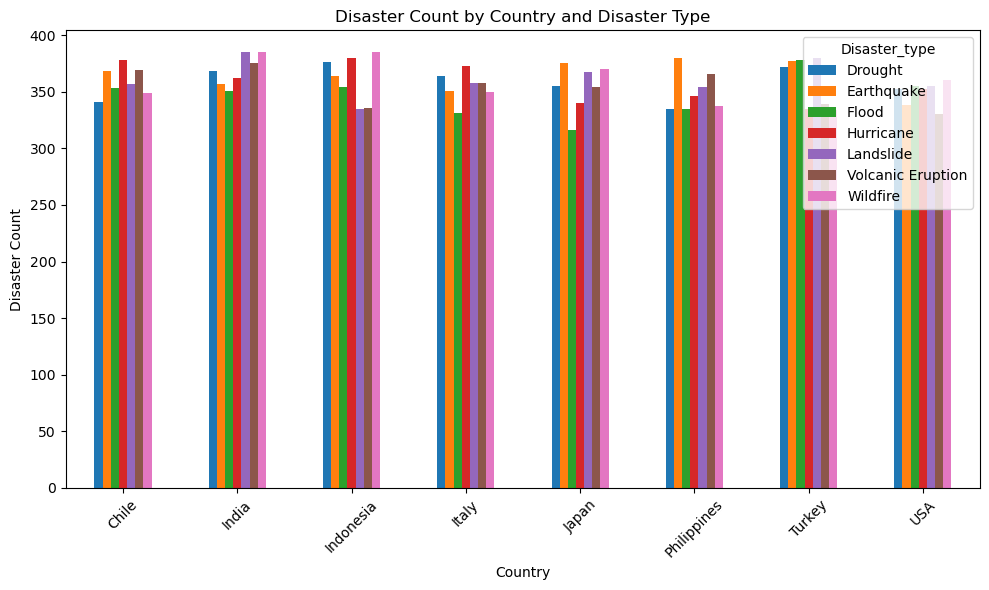

In [81]:
pivot_table.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Disaster Count by Country and Disaster Type')
plt.xlabel('Country')
plt.ylabel('Disaster Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


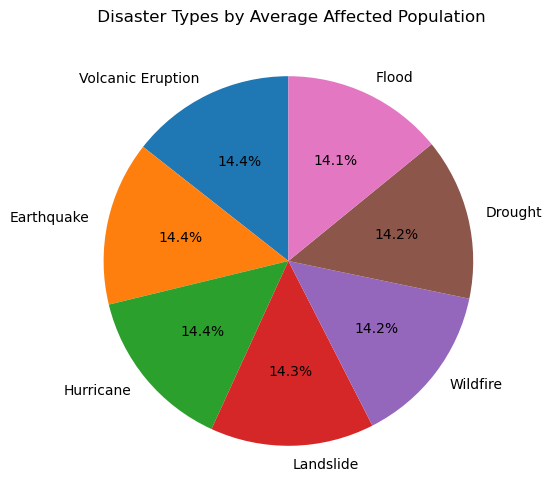

In [82]:
disasters_affected_population.plot(
    kind='pie',
    figsize=(10,6),
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel('')
plt.title(' Disaster Types by Average Affected Population')
plt.show()


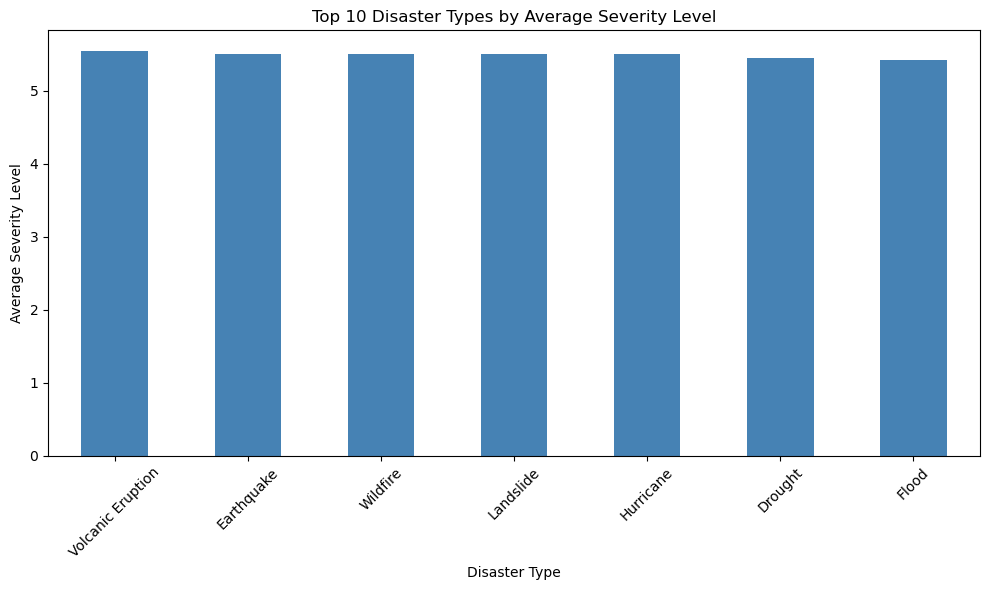

In [83]:
disaster_severity_level.plot(
    kind='bar',
    figsize=(10,6),
    color='steelblue'
)

plt.xlabel('Disaster Type')
plt.ylabel('Average Severity Level')
plt.title('Top 10 Disaster Types by Average Severity Level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


<Axes: xlabel='Location'>

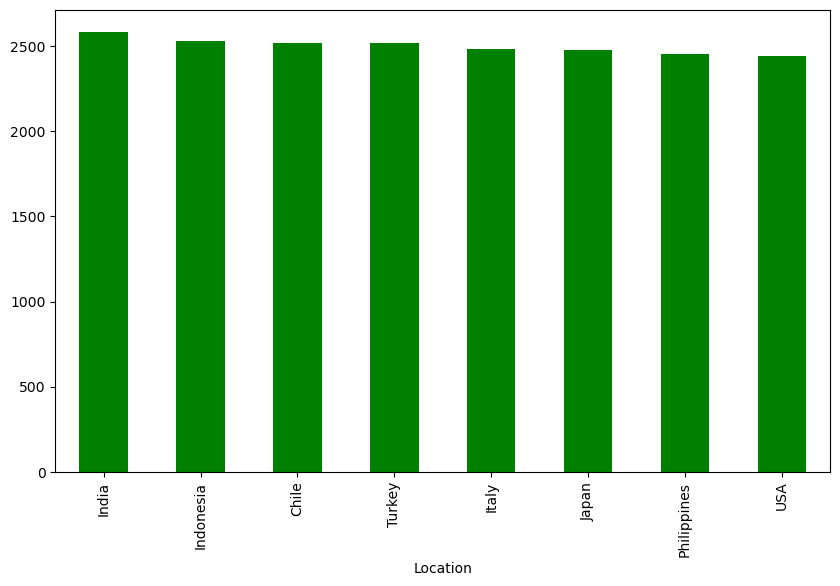

In [84]:
location_disaster.plot(
    kind='bar',
    figsize=(10,6),
    color='green'
)

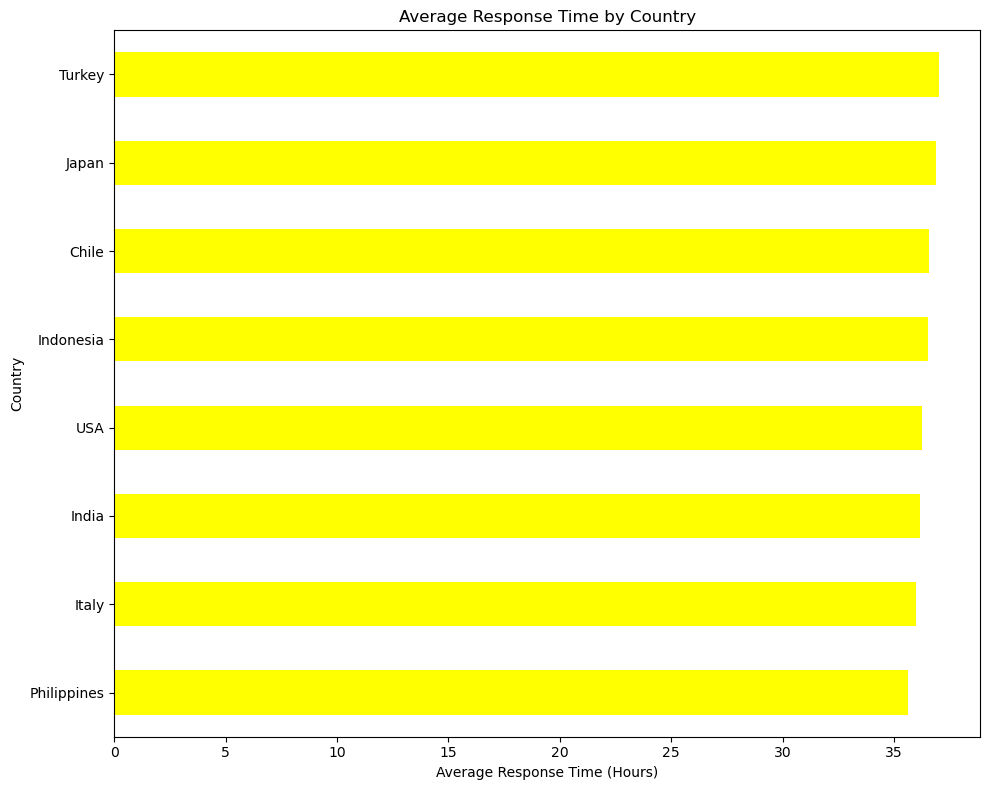

In [85]:
countries_avg_response_time.sort_values().plot(
    kind='barh',
    color ='yellow',
    figsize=(10,8)
)

plt.xlabel('Average Response Time (Hours)')
plt.ylabel('Country')
plt.title('Average Response Time by Country')
plt.tight_layout()
plt.show()


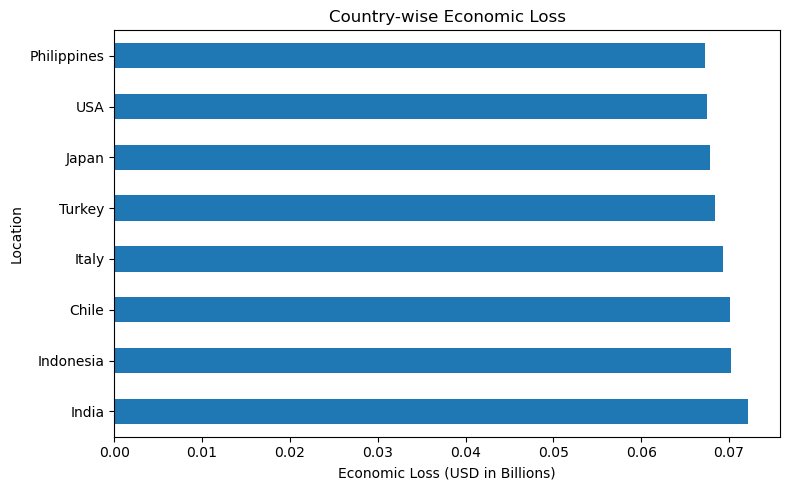

In [86]:
(countryies_affected_population / 1e9).plot(
    kind='barh',
    figsize=(8,5)
)

plt.xlabel('Economic Loss (USD in Billions)')
plt.ylabel('Location')
plt.title('Country-wise Economic Loss')
plt.tight_layout()
plt.show()


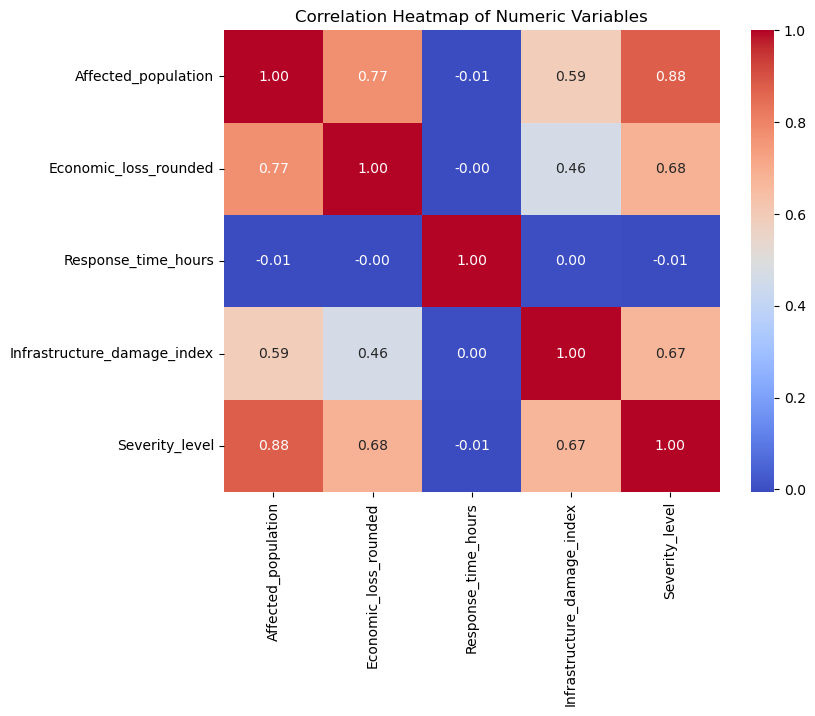

In [87]:
numeric_cols = [
    'Affected_population',
    'Economic_loss_rounded',
    'Response_time_hours',
    'Infrastructure_damage_index',
    'Severity_level'
]

plt.figure(figsize=(8,6))
sns.heatmap(
    data[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

In [88]:
countryies_affected_severity_level = (
    data
    .groupby(['Location', 'Year'])
    .size()
    .reset_index(name='Disaster_Count')
)


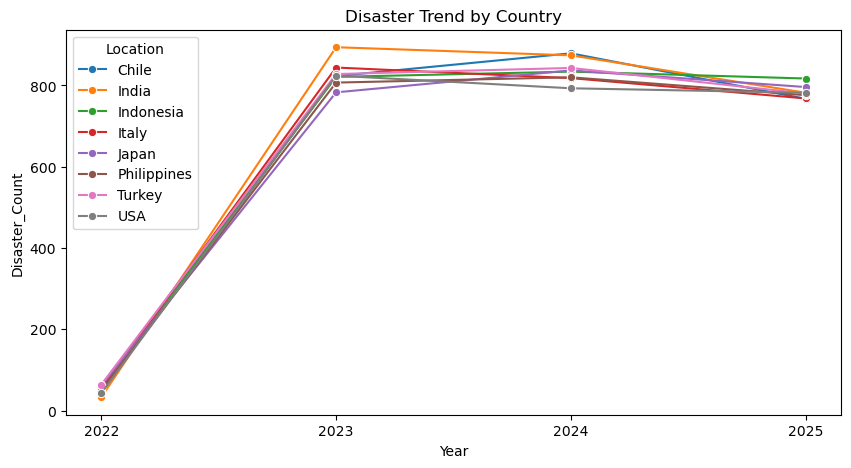

In [89]:
plt.figure(figsize=(10,5))
sns.lineplot(
    data=countryies_affected_severity_level,
    x='Year',
    y='Disaster_Count',
    hue='Location',
    marker='o'
)
years = sorted(countryies_affected_severity_level['Year'].unique())
plt.xticks(years)
plt.title('Disaster Trend by Country')
plt.show()

## **Overall Insights**
- Most disasters occurred during **2022–2023**.
- **Volcanic eruptions** show the **highest severity levels**.
- Higher **severity levels** lead to increased **affected population**, **economic loss**, and **infrastructure damage**.

## **Country-wise Insights**

### **India**
- Highest **disaster count**.
- Major disasters: **landslides, wildfires, volcanic eruptions**.
- Low **response time** but high **population impact and economic loss**.

### **Chile**
- Mainly affected by **hurricanes and volcanic eruptions**.
- High **severity level** and **infrastructure damage**.

### **Indonesia**
- Second-highest **disaster count**.
- Major impact on **population and economic loss**.

### **Italy**
- Frequent **hurricanes, droughts, and landslides**.

### **Japan**
- Mostly affected by **earthquakes, wildfires, and landslides**.

### **Philippines**
- Common disasters: **earthquakes, volcanic eruptions, landslides**.

### **Turkey**
- Major disasters include **landslides, floods, and earthquakes**.
- Impact and response metrics show **low variation**.

### **United States**
- Lower **disaster count** and **overall impact** compared to other countries.

## **Trend Summary**
- Disaster events show an **increasing trend** in recent years.
- **Severity and frequency** are the key drivers of disaster impact.
